# ДЗ Линейная регрессия

В данном задании мы рассмотрим набор данных об учащихся, собранный в 2006 году в одной из школ Португалии. Данные представлены в неудобном для машинного обучения виде, и содержат мусор. Ваша задача &mdash; привести их к надлежащему виду и обучить на них простую модель.

Данные состоят из четырех файлов:
- data.csv &mdash; основная таблица с информацией о учащихся
- scores.csv &mdash; список финальных оценок по одному из предметов (20-балльная шкала переведенная в проценты)
- attendance.csv &mdash; таблица посещений занятий по этому предмету
- school_support.txt &mdash; список учащихся, которым оказывается финансовая поддержка

Ваша задача &mdash; построить модель для предсказания финальных оценок исходя из всех остальных данных и проверить качество ее работы с помощью кросс-валидации. В качестве алгоритма мы будем использовать линейную регрессию

Расшифровка столбцов в data.csv для справки:
- age &mdash; возраст
- Medu &mdash; уровень образования матери (по некоторой условной шкале)
- Fedu &mdash; уровень образования отца (по некоторой условной шкале)
- traveltime &mdash; время в пути до школы (1 – < 15 мин., 2 – от 15 до 30 мин., 3 – от 30 мин. to 1 ч.
или 4 – > 1 ч.)
- studytime &mdash; время, затрачиваемое на занятия вне школы (1 – < 2 ч., 2 – от 2 до 5 ч., 3 – от 5 до 10 ч. или 4 – > 10 ч.)
- famrel &mdash; насколько хорошие отношения в семье у учащегося (по некоторой условной шкале)
- freetime &mdash; количество свободного времени вне школы (по некоторой условной шкале)
- goout &mdash; время, затрачиваемое на общение с друзьями (по некоторой условной шкале)
- Dalc &mdash; количество употребления алкоголя в учебные дни (по некоторой условной шкале)
- Walc &mdash; количество употребления алкоголя в неучебные дни (по некоторой условной шкале)
- health &mdash; уровень здоровья (по некоторой условной шкале)
- sex_M &mdash; пол: мужской (1) или женский (0)
- address_U &mdash; живет ли учащийся в городе (1) или в пригороде (0)
- famsize_LE3 &mdash; размер семьи: не больше 3 человек (1) или больше (0)
- Pstatus_T &mdash; живут ли родители вместе (1) или отдельно (0)
- nursery &mdash; посещал ли учащийся детский сад
- plans_university &mdash; планирует ли учащийся поступать в университет (-1 или 1)
- past_failures &mdash; количество неудовлетворительных оценок по другим предметам ранее (от 0 до 4)

*Примечание. Несколько признаков в данных содержат ошибки/проблемы/некорректности. Эти проблемы нужно исправить. Для
проверки &mdash; всего в данных таких проблем четыре.*

In [ ]:
pip install pandas

In [ ]:
pip install scikit-learn

### Задача 1: сломанный признак (а может и не один)
__(1 балл)__

Загрузите таблицу data.csv.

Найдите в данных сломанный признак (он не соответствует описанию) и исправьте его.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import os

data = pd.read_csv('/content/drive/MyDrive/MachineLearning/taks2_linreg_2024/task/data.csv')

def fixage(x):
    if (x > 1950):
        return 2006 - x
    else:
        return x

def fixtraveltime(x):
    if (x > 4):
        if (x < 15):
            return 1
        elif (x < 30):
            return 2
        elif (x < 60):
            return 3
        else:
            return 4
    else:
        return x

def fixstudytime(x):
    if (x > 4):
        if (x < 5):
            return 2
        elif (x < 10):
            return 3
        else:
            return 4
    else:
        return x

def split_combined_column(x):
    failures = abs(x%10)
    university = x//10
    return university, failures

split_data = data['plans_universitypast_failures'].apply(split_combined_column)
data['plans_university'] = split_data.apply(lambda x: x[0])
data['past_failures'] = split_data.apply(lambda x: x[1])

data['age'] = data['age'].apply(fixage)
data['traveltime'] = data['traveltime'].apply(fixtraveltime)
data['studytime'] = data['studytime'].apply(fixstudytime)

data = data.drop(columns=['plans_universitypast_failures'])

data.head()

,age,Medu,Fedu,traveltime,studytime,famrel,freetime,goout,Dalc,Walc,health,sex_M,address_U,famsize_LE3,Pstatus_T,nursery,plans_university,past_failures
0,16,4,4,1,2,5,4,4.0,1.0,2.0,5,1,1,0,1,1,1,0
1,17,4,4,1,1,5,3,4.0,1.0,2.0,5,0,1,0,1,1,1,0
2,16,1,1,2,1,4,5,5.0,2.0,4.0,5,1,0,1,1,1,1,0
3,18,1,2,2,1,3,4,4.0,2.0,4.0,4,1,1,0,1,0,-1,0
4,17,2,1,2,2,4,2,5.0,1.0,2.0,5,0,0,0,1,1,1,0


### Задача 2: пропуски в данных
__(1 балл)__

Проверьте, есть ли в данных пропуски (значения NaN). Замените все пропущенные значения на среднее значение этого признака по столбцу.

*Hint: изучите в pandas функции loc, isnull, а также передачу булевых массивов в качестве индексов.*

In [ ]:
data = data.fillna(data.mean())

### Задача 3: нормализация данных
__(1 балл)__

Нормализуйте данные любым способом

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

data_normalized = data.copy()
numeric_columns = data.select_dtypes(include=['int64', 'float64']).columns
data_normalized[numeric_columns] = scaler.fit_transform(data[numeric_columns])

### Задача 4: кросс-валидация для исходных данных
__(1 балл)__

Загрузите файл scores.csv и протестируйте, как линейная регрессия предсказывает ответ сейчас (с помощью кросс-валидации).

Кроссвалидацию сделайте по 4 разбивкам. Выведите качество в каждом их разбиений.

*Hint: воспользуйтесь sklearn.linear_model и sklearn.model_selection.*

In [ ]:
scores = pd.read_csv('/content/drive/MyDrive/MachineLearning/taks2_linreg_2024/task/scores.csv', header=None, names=['score'])

def fixscores(x):
    if (x < 1):
        return 100*x
    else:
        return x

scores['score'] = scores['score'].apply(fixscores)

data_scores = data_normalized.copy()
data_scores['score'] = scores['score']

data_scores.head()

,age,Medu,Fedu,traveltime,studytime,famrel,freetime,goout,Dalc,Walc,health,sex_M,address_U,famsize_LE3,Pstatus_T,nursery,plans_university,past_failures,score
0,-0.611422,1.310216,1.540715,-0.760032,0.083653,1.119748,0.780478,0.692772,-0.542692,-0.223769,1.012903,1.199937,0.660182,-0.648175,0.374963,0.495663,0.337331,-0.302247,70.0
1,0.210137,1.310216,1.540715,-0.760032,-1.122808,1.119748,-0.171647,0.692772,-0.542692,-0.223769,1.012903,-0.833377,0.660182,-0.648175,0.374963,0.495663,0.337331,-0.302247,85.0
2,-0.611422,-1.336039,-1.188832,0.576718,-1.122808,0.072606,1.732603,1.544607,0.547811,1.340184,1.012903,1.199937,-1.514733,1.542792,0.374963,0.495663,0.337331,-0.302247,45.0
3,1.031695,-1.336039,-0.278983,0.576718,-1.122808,-0.974536,0.780478,0.692772,0.547811,1.340184,0.320930,1.199937,0.660182,-0.648175,0.374963,-2.017502,-2.223230,-0.302247,55.0
4,0.210137,-0.453954,-1.188832,0.576718,0.083653,0.072606,-1.123771,1.544607,-0.542692,-0.223769,1.012903,-0.833377,-1.514733,-0.648175,0.374963,0.495663,0.337331,-0.302247,55.0


In [ ]:
X = data_scores.drop('score', axis=1)
y = data_scores['score']

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import numpy as np

model = LinearRegression()
kf = KFold(n_splits=4, shuffle=True, random_state=1448)

scores_kfold = []

for train_index, test_index in kf.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    score = r2_score(y_test, y_pred)
    scores_kfold.append(score)

print("R2 scores for each fold:")
for i, score in enumerate(scores_kfold, 1):
    print(f"Fold {i}: {score:.4f}")

R2 scores for each fold:
Fold 1: 0.1113
Fold 2: 0.2615
Fold 3: 0.2428
Fold 4: 0.2021


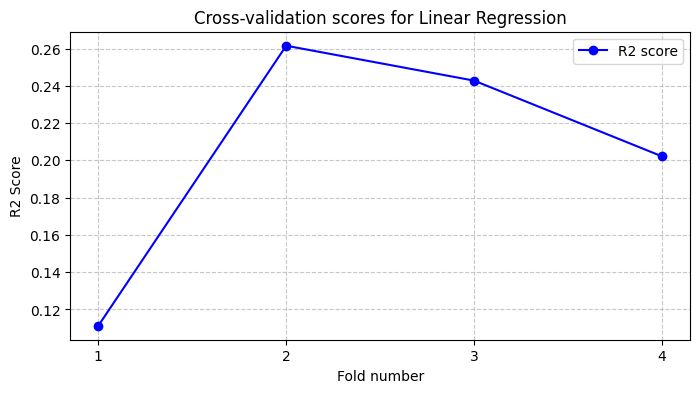

Mean R2 score: 0.2044


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(range(1, 5), scores_kfold, 'bo-', label='R2 score')
plt.xlabel('Fold number')
plt.ylabel('R2 Score')
plt.title('Cross-validation scores for Linear Regression')
plt.xticks(range(1, 5))
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

print(f"Mean R2 score: {np.mean(scores_kfold):.4f}")

### Задача 5: полные данные
__(2 балла)__

Воспользуйтесь файлами attendance.csv и school_support.txt для того, чтобы добавить новые признаки в данные. Желательно по максимуму использовать возможности pandas для упрощения преобразований.

school_suport число в строке значит что i-ый школьник из исходной таблицы получал мат помощь (обратите внимание что строк в файле меньше, подумайте как правильно импортировать данные)

Добавьте данные таким образом, чтобы качество выросло

In [ ]:
attendance = pd.read_csv('/content/drive/MyDrive/MachineLearning/taks2_linreg_2024/task/attendance.csv', header=0, names=['www'])
def fixaverage(x):
  s = str(x)
  p = s.count('+')
  return p/32;

attendance['attendance_rate'] = attendance['www'].apply(fixaverage)

attendance.head()

,www,attendance_rate
0,+;+;+;+;+;+;+;;;+;;+;+;;+;+;+;+;+;+;+;+;+;+;+;...,0.8125
1,+;;+;+;+;+;+;+;+;+;+;+;+;+;+;+;+;+;;+;+;+;+;+;...,0.9375
2,+;+;+;+;+;+;+;+;+;+;+;+;+;+;+;+;+;+;+;+;+;+;+;...,1.0000
3,+;+;;;+;+;+;+;;;+;;+;;+;;+;;+;+;+;+;+;+;+;+;+;...,0.6875
4,+;+;+;+;+;+;+;+;+;+;+;+;+;+;+;+;+;+;+;+;+;+;+;...,1.0000


In [ ]:

school_support = pd.read_csv('/content/drive/MyDrive/MachineLearning/taks2_linreg_2024/task/school_support.txt', header=None, names=['support'])


data_scores = data_scores.merge(
    attendance[['attendance_rate']],
    left_index=True,
    right_index=True,
    how='left'
)

data_scores['school_support'] = 0
data_scores.loc[school_support['support'], 'school_support'] = 1

X = data_scores.drop('score', axis=1)
y = data_scores['score']

model = LinearRegression()
kf = KFold(n_splits=4, shuffle=True, random_state=1448)

scores_kfold = []

for train_index, test_index in kf.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    score = r2_score(y_test, y_pred)
    scores_kfold.append(score)

print("R2 scores for each fold:")
for i, score in enumerate(scores_kfold, 1):
    print(f"Fold {i}: {score:.4f}")

R2 scores for each fold:
Fold 1: 0.1142
Fold 2: 0.2715
Fold 3: 0.2229
Fold 4: 0.2167


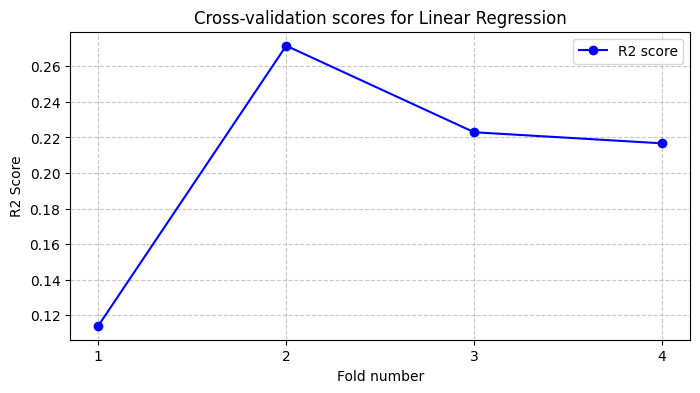

Mean R2 score: 0.2063


In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, 5), scores_kfold, 'bo-', label='R2 score')
plt.xlabel('Fold number')
plt.ylabel('R2 Score')
plt.title('Cross-validation scores for Linear Regression')
plt.xticks(range(1, 5))
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

print(f"Mean R2 score: {np.mean(scores_kfold):.4f}")

In [ ]:
data_scores.head(10)

,age,Medu,Fedu,traveltime,studytime,famrel,freetime,goout,Dalc,Walc,...,sex_M,address_U,famsize_LE3,Pstatus_T,nursery,plans_university,past_failures,score,attendance_rate,school_support
0,-0.611422,1.310216,1.540715,-0.760032,0.083653,1.119748,0.780478,0.692772,-0.542692,-0.223769,...,1.199937,0.660182,-0.648175,0.374963,0.495663,0.337331,-0.302247,70.0,0.8125,0
1,0.210137,1.310216,1.540715,-0.760032,-1.122808,1.119748,-0.171647,0.692772,-0.542692,-0.223769,...,-0.833377,0.660182,-0.648175,0.374963,0.495663,0.337331,-0.302247,85.0,0.9375,0
2,-0.611422,-1.336039,-1.188832,0.576718,-1.122808,0.072606,1.732603,1.544607,0.547811,1.340184,...,1.199937,-1.514733,1.542792,0.374963,0.495663,0.337331,-0.302247,45.0,1.0000,0
3,1.031695,-1.336039,-0.278983,0.576718,-1.122808,-0.974536,0.780478,0.692772,0.547811,1.340184,...,1.199937,0.660182,-0.648175,0.374963,-2.017502,-2.223230,-0.302247,55.0,0.6875,0
4,0.210137,-0.453954,-1.188832,0.576718,0.083653,0.072606,-1.123771,1.544607,-0.542692,-0.223769,...,-0.833377,-1.514733,-0.648175,0.374963,0.495663,0.337331,-0.302247,55.0,1.0000,0
5,0.210137,-0.453954,1.540715,-0.760032,0.083653,0.072606,-0.171647,-1.010896,-0.542692,-1.005746,...,-0.833377,0.660182,1.542792,0.374963,0.495663,0.337331,-0.302247,80.0,0.7500,0
6,-1.432980,-1.336039,-1.188832,1.913468,0.083653,0.072606,-1.123771,-1.862730,-0.542692,-0.223769,...,-0.833377,-1.514733,-0.648175,0.374963,0.495663,0.337331,-0.302247,70.0,1.0000,0
7,-1.432980,0.428131,0.630866,-0.760032,2.496576,0.072606,-0.171647,-0.159062,-0.542692,-1.005746,...,-0.833377,0.660182,-0.648175,-2.666927,0.495663,0.337331,-0.302247,50.0,0.6875,1
8,1.853254,-1.336039,-1.188832,1.913468,-1.122808,0.072606,0.780478,0.692772,1.638314,0.558207,...,1.199937,-1.514733,-0.648175,0.374963,0.495663,0.337331,0.227910,50.0,0.8750,0
9,0.210137,-1.336039,-1.188832,-0.760032,1.290114,0.072606,-0.171647,-1.010896,-0.542692,-0.223769,...,-0.833377,0.660182,1.542792,0.374963,0.495663,0.337331,-0.302247,50.0,0.6875,0


### Задача 6: борьба с выбросами
__(1.5 балла)__

Качество предсказания может ухудшаться, если в данных присутствуют корректные значения признаков (с точки зрения чтения данных и применения методов), но не соответствующие реальным объектам. Например, данные могли быть введены в неверном формате, а потом слишком грубо приведены к общему виду, из-за чего ошибка не была замечена.
Попробуем от такого избавиться &mdash; а для этого такие объекты нужно сначала найти. Конечно, нам еще недоступны многие продвинутые способы, но давайте попробуем обойтись простыми.

Первый способ это сделать &mdash; посмотреть для каждого признака на распределение его значений и проверить крайние значения на правдоподобность. (постройте гистограммы для признаков, как минимум для подозрительных)

*Hint 1: используйте функцию DataFrame.hist*

*Hint 2: в описании датасета выше есть информация, необходимая для восстановления правильных значений*

In [ ]:
# Your code here
# ...

__(1.5 балла)__

Другой простой способ найти выбросы &mdash; сделать предсказание и посчитать ошибку на каждом объекте по отдельности и посмотреть на объекты с наибольшей ошибкой. Обучите линейную регрессию (функция fit) и для каждого объекта посчитайте среднеквадратичное отклонение. Постройте гистограмму распределения ошибок. Посмотрите на гистограмму и удалите из выборки те объекты на которых ошибка слишком большая.

Обратите внимание, что просто удалять все объекты с высокой ошибкой нельзя &mdash; это, конечно, хороший способ добиться меньшей ошибки (на данной выборке), но одновременно вы ухудшите обобщающую способность алгоритма. Вместо этого вам нужно найти однозначно ошибочные записи и их исправить.

*Hint: возможно, все проблемы уже были найдены первым способом; для проверки &mdash; в сумме здесь нужно исправить 3 проблемы.*

Для поиска ошибки на одном отдельном обьекте придётся обучить линейную регрессию руками. Частичный пример, допишите код. Постройте гистограмму распределения ошибок

In [ ]:
import sklearn
from sklearn import linear_model
regression = linear_model.LinearRegression().fit(data, result) #create model and train it
prediction = #calculate prediction for one object for vector x
error = (prediction - y)**2 #simple error - square error

SyntaxError: invalid syntax (3289234131.py, line 4)

In [ ]:
# Your code here
# ...

### Финальное предсказание и отчёт (1 балл)

Проведите предсказание еще раз и сравните качество с исходным. Запишите свои наблюдения - как изменялось качество обучения модели при использовании разных модификаций данных.

In [ ]:
# Your code here
# ...

In [2]:
# -*- coding: utf-8 -*-
"""
weierstrass_dark_bg.py
Плотный минималистичный график
f(x) = sum_{n=0}^{∞} (1/2)^n cos(3^n x), x in [-1,1],
на чёрном фоне, линия цветом RGB(217,221,226).
"""

import numpy as np
import matplotlib.pyplot as plt

# ---------- Параметры (при необходимости можно изменить) ----------
N = 12                 # число членов суммы (частичная сумма)
samples = 20000        # количество точек по x (чем больше — тем плавнее)
linewidth = 4.0        # толщина линии (примерно 5× "тонкой")
margin = 0.08          # относительный отступ по краям фигуры
outfile = "weierstrass_dark.png"
dpi_out = 600          # выходное разрешение (высокое)
figsize = (9, 3)       # размер фигуры (ширина, высота) в дюймах
# ---------------------------------------------------

# цвет линии в нормализованном виде (0..1)
line_rgb = (217/255.0, 221/255.0, 226/255.0)

# x-ось
x = np.linspace(-1.0, 1.0, samples, endpoint=True)

# вычисление частичной суммы по n
ns = np.arange(N, dtype=np.float64)
coeffs = (0.5) ** ns
freqs = (3 ** ns)

y = np.zeros_like(x)
for c, k in zip(coeffs, freqs):
    y += c * np.cos(k * x)

# границы y с небольшим запасом, чтобы кривая не упиралась в рамку
ymin, ymax = y.min(), y.max()
yrange = ymax - ymin
if yrange == 0:
    yrange = 1.0
ypad = 0.03 * yrange
ylim = (ymin - ypad, ymax + ypad)

# создаём фигуру с чёрным фоном
fig = plt.figure(figsize=figsize, dpi=300)
fig.patch.set_facecolor('black')

# размещение осей так, чтобы были равные поля по краям
left = margin
bottom = margin
width = 1.0 - 2.0 * margin
height = 1.0 - 2.0 * margin
ax = fig.add_axes([left, bottom, width, height])
ax.set_facecolor('black')

# важное требование: масштаб осей x/y = 3/1
# В matplotlib параметр aspect = (y_unit_length / x_unit_length).
# Для x/y = 3/1 используем aspect = 1/3.
ax.set_aspect(1.0 / 3.0, adjustable='box')

# рисуем кривую: сплошная, цвет заданный, толстая, острые концы
ax.plot(x, y,
        color=line_rgb,
        linewidth=linewidth,
        antialiased=True,
        solid_capstyle='round',
        solid_joinstyle='round')

# ограничиваем видимую область, убираем оси/метки/текст
ax.set_xlim(-1.0, 1.0)
ax.set_ylim(ylim)
ax.axis('off')

# сохраняем изображение высокого качества.
# НЕ используем bbox_inches='tight', чтобы сохранить ровные белые (чёрные) поля.
plt.savefig(outfile, dpi=dpi_out, facecolor=fig.get_facecolor(), edgecolor='none', transparent=False)
plt.close(fig)

print(f"Сохранено: {outfile}  (dpi={dpi_out}, samples={samples}, N={N})")


Сохранено: weierstrass_dark.png  (dpi=600, samples=20000, N=12)
